# 最基礎的 Simple Linear Regression, 透過 OLS (Ordinary Least Squares, 普通最小平方法)

計算 SXY SXX 得到 B1，接著透過B1 計算 B0，最後透過兩B計算RSS

intercept 結距 -> B0,
slope 斜率 -> B1

手動計算的截距 (beta_0): 1.1934
手動計算的斜率 (beta_1): 1.9553


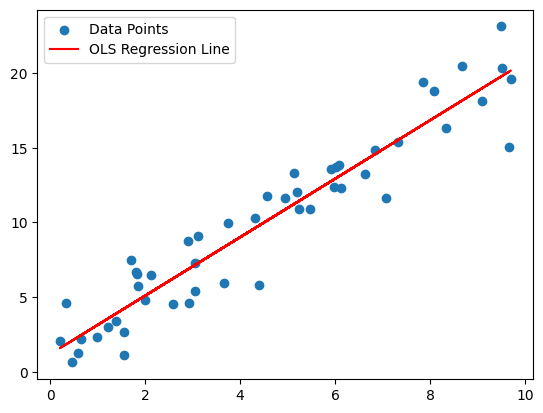

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 建立一些模擬的假資料
np.random.seed(42)
x = np.random.rand(50) * 10
# 假設真實世界的關係是 y = 2x + 1，並加入一點隨機雜訊
y = 2 * x + 1 + np.random.randn(50) * 2

# 放入 DataFrame
df = pd.DataFrame({'X': x, 'Y': y})

# 2. 嚴格對照投影片的數學公式進行手算！
# 計算平均值
x_mean = df['X'].mean()
y_mean = df['Y'].mean()

# 計算 SXY (分子): sum((xi - x_mean) * (yi - y_mean))
SXY = ((df['X'] - x_mean) * (df['Y'] - y_mean)).sum()

# 計算 SXX (分母): sum((xi - x_mean)^2)
SXX = ((df['X'] - x_mean)**2).sum()

# 根據公式算出斜率 (beta_1) 和截距 (beta_0)
beta_1 = SXY / SXX
beta_0 = y_mean - beta_1 * x_mean

print(f"手動計算的截距 (beta_0): {beta_0:.4f}")
print(f"手動計算的斜率 (beta_1): {beta_1:.4f}")

# 3. 畫圖看看我們擬合的結果
plt.scatter(df['X'], df['Y'], label='Data Points')
# 畫出我們的預測線 y = beta_0 + beta_1 * x
plt.plot(df['X'], beta_0 + beta_1 * df['X'], color='red', label='OLS Regression Line')
plt.legend()
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# 告訴套件：我們要用 X 去預測 Y (Y ~ X)
# OLS 就代表 Ordinary Least Squares (普通最小平方法)
stat_model = smf.ols(formula='Y ~ X', data=df).fit() # ols == Ordinary Least Squares

print(stat_model.summary())

# Intercept 的 coef 欄位就是 beta_0 (截距)。
# X 的 coef 欄位就是 beta_1 (斜率)。

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     455.9
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           3.75e-26
Time:                        22:48:53   Log-Likelihood:                -100.74
No. Observations:                  50   AIC:                             205.5
Df Residuals:                      48   BIC:                             209.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1934      0.485      2.460      0.0

----
----

# 檢驗計算的東西，透過 R2

RSS 可以很小但還是不准，所以要透過 R2

In [3]:
import numpy as np

# 假設 df['Y'] 是真實數據，y_pred 是你的模型預測出來的結果
y_true = df['Y']
y_pred = beta_0 + beta_1 * df['X']  # 這是我們剛剛算出的預測線

# 1. 計算 Y 的平均值
y_mean = y_true.mean()

# 2. 計算總變異 (SSY)
SSY = ((y_true - y_mean) ** 2).sum()

# 3. 計算殘差平方和 (RSS)
RSS = ((y_true - y_pred) ** 2).sum()

# 4. 算出 R-squared
r_squared_manual = 1 - (RSS / SSY)

print(f"手動計算的 R^2: {r_squared_manual:.4f}")

手動計算的 R^2: 0.9047


In [4]:
from sklearn.metrics import r2_score

# 直接丟入「真實答案」跟「預測答案」
r_squared_sklearn = r2_score(y_true, y_pred)

print(f"sklearn 計算的 R^2: {r_squared_sklearn:.4f}")

sklearn 計算的 R^2: 0.9047


In [5]:
import statsmodels.formula.api as smf

# 建立並訓練模型
stat_model = smf.ols(formula='Y ~ X', data=df).fit()

# 直接從模型結果中提取 R-squared 屬性
r_squared_sm = stat_model.rsquared

print(f"statsmodels 報表中的 R^2: {r_squared_sm:.4f}")

statsmodels 報表中的 R^2: 0.9047


----
----

# 另一個模型 GLM

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 準備跟之前一樣的模擬資料 (真實關係是 y = 2x + 1)
np.random.seed(42)
x = np.random.rand(50) * 10
y = 2 * x + 1 + np.random.randn(50) * 2
df = pd.DataFrame({'X': x, 'Y': y})

# ==========================================
# 2. 舊世界觀：使用 OLS (最小化誤差平方和 RSS)
# ==========================================
ols_model = smf.ols(formula='Y ~ X', data=df).fit()

# ==========================================
# 3. 新世界觀：使用 GLM 進行 MLE (最大化機率 Likelihood)
# 這裡的 Gaussian() 就是投影片裡假設的 Normal distribution
# ==========================================
mle_model = smf.glm(formula='Y ~ X', data=df, family=sm.families.Gaussian()).fit()

# ==========================================
# 4. 見證奇蹟的時刻：比較兩者的結果
# ==========================================
print("=== OLS 算出來的參數 (beta_0, beta_1) ===")
print(ols_model.params)
print("-" * 40)
print("=== MLE 算出來的參數 (beta_0, beta_1) ===")
print(mle_model.params)
print("-" * 40)

# 我們把他們算出來的 Log-Likelihood (對數概似值) 也印出來看看
print(f"OLS 的 Log-Likelihood: {ols_model.llf:.4f}")
print(f"MLE 的 Log-Likelihood: {mle_model.llf:.4f}")

print(mle_model.summary())

=== OLS 算出來的參數 (beta_0, beta_1) ===
Intercept    1.193379
X            1.955313
dtype: float64
----------------------------------------
=== MLE 算出來的參數 (beta_0, beta_1) ===
Intercept    1.193379
X            1.955313
dtype: float64
----------------------------------------
OLS 的 Log-Likelihood: -100.7365
MLE 的 Log-Likelihood: -100.7365
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   50
Model:                            GLM   Df Residuals:                       48
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          3.4295
Method:                          IRLS   Log-Likelihood:                -100.74
Date:                Sun, 26 Apr 2026   Deviance:                       164.61
Time:                        23:39:32   Pearson chi2:                     165.
No. Iterations:                 

----
----

# PI（預測區間）永遠比 CI（信心區間）

In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 1. 建立假資料
np.random.seed(42)
x = np.random.normal(10, 3, 50)
y = 1.5 * x + 5 + np.random.normal(0, 4, 50)
df = pd.DataFrame({'X': x, 'Y': y})

# 2. 建立並訓練模型
model = smf.ols('Y ~ X', data=df).fit()

# 3. 假設我們要預測 X = 12 的情況
new_data = pd.DataFrame({'X': [12]})

# 4. 呼叫大絕招：取得預測與所有區間！
predictions = model.get_prediction(new_data)
pred_summary = predictions.summary_frame(alpha=0.05) # alpha=0.05 代表 95% 區間

print(pred_summary)

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  23.438955  0.690308      22.050998      24.826913     16.242352   

   obs_ci_upper  
0     30.635559  
